In [1]:
!pip install ortools
!pip install matplotlib

In [2]:
import json
import os
import glob
import gc
import re
import subprocess
import tempfile
import torch
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/opt/venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


ERROR 05-04 01:17:21 [gpt_oss_triton_kernels_moe.py:34] Failed to import Triton kernels. Please make sure your triton version is compatible. Error: No module named 'triton_kernels.routing'
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:

# Load Validation Data 
with open("/workspace/ro4_reinforcement-learning/data/trip_planning_val_48.json", "r", encoding="utf-8") as f:
    val_data_raw = json.load(f)
val_data_list = list(val_data_raw.values()) if isinstance(val_data_raw, dict) else val_data_raw

# We now need the prompt, cities, and durations to generate native ground truth
eval_dataset = []
for item in val_data_list:
    eval_dataset.append({
        "prompt": item.get("prompt_0shot") or item.get("prompt"),
        "cities": item.get("cities", ""),
        "durations": item.get("durations", "")
    })
print(f"Loaded {len(eval_dataset)} validation prompts.")

Loaded 48 validation prompts.


In [4]:
def extract_code(text):
    """Extracts python code from the generated text."""
    pattern = r"```python\n(.*?)```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return None

def extract_json_from_output(output_str):
    """Safely extracts JSON from stdout, ignoring extra print statements."""
    try:
        start_idx = output_str.find('[')
        end_idx = output_str.rfind(']')
        start_dict = output_str.find('{')
        end_dict = output_str.rfind('}')
        
        if start_idx != -1 and end_idx != -1 and (start_dict == -1 or start_idx < start_dict):
            return json.loads(output_str[start_idx:end_idx+1])
        elif start_dict != -1 and end_dict != -1:
            return json.loads(output_str[start_dict:end_dict+1])
    except json.JSONDecodeError:
        pass
    return None

def test_code_execution(code_string):
    """
    Runs the code.
    Returns: (is_syntax_valid: bool, msg: str, generated_json: list/dict or None)
    """
    if not code_string:
        return False, "Failed to extract code.", None
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as temp_file:
        temp_file.write(code_string)
        temp_file_path = temp_file.name

    try:
        result = subprocess.run([sys.executable, temp_file_path], capture_output=True, text=True, timeout=10)
        
        if result.returncode != 0:
            return False, f"Execution Error: {result.stderr.strip()[-100:]}", None
        
        output = result.stdout.strip()
        
        # CHANGED: Removed the period to catch when the model forgets it
        if "No solution" in output:
             return True, "Valid Execution (No solution feasible)", "No solution found."
             
        # CHANGED: Use the robust JSON extractor
        parsed_json = extract_json_from_output(output)
        if parsed_json is not None:
            return True, "Valid Execution (JSON output)", parsed_json
        else:
            return False, "Executed, but output was not valid JSON.", None
            
    except subprocess.TimeoutExpired:
        return False, "Execution Timeout (>10 seconds).", None
    finally:
        if os.path.exists(temp_file_path):
            os.remove(temp_file_path)

def get_ground_truth(cities_str, durations_str):
    if not cities_str or not durations_str:
        return []
    cities = cities_str.split("**")
    durations = [int(d) for d in durations_str.split("**")]
    
    gt = []
    current_start = 1
    for c, d in zip(cities, durations):
        end = current_start + d - 1
        gt.append({
            "city": c.strip().lower(), # CHANGED: lowercased to prevent string mismatch
            "start": current_start,
            "end": end
        })
        current_start = end
    return gt

def safe_int(x):
    try:
        return int(x)
    except:
        return None

def normalize(plan):
    cleaned = []

    # --- 1. Structured dict format ---
    if isinstance(plan, dict) and all(k in plan for k in ["order", "start_times", "end_times"]):
        for city in plan["order"]:
            s = safe_int(plan["start_times"].get(city))
            e = safe_int(plan["end_times"].get(city))
            if s is not None and e is not None:
                cleaned.append({
                    "city": str(city).strip().lower(),
                    "start": s,
                    "end": e
                })
        return sorted(cleaned, key=lambda x: x["start"])

    # --- 2. Unwrap nested formats ---
    if isinstance(plan, dict):
        for key in ["solutions", "trip_plan", "plan", "schedule"]:
            if key in plan:
                return normalize(plan[key])

    # --- 3. Dict-of-arrays format ---
    if isinstance(plan, dict):
        for city, dates in plan.items():
            if isinstance(dates, list) and len(dates) >= 2:
                s = safe_int(dates[0])
                e = safe_int(dates[1])
                if s is not None and e is not None:
                    cleaned.append({
                        "city": str(city).strip().lower(),
                        "start": s,
                        "end": e
                    })
        if cleaned:
            return sorted(cleaned, key=lambda x: x["start"])

    # --- 4. List of dicts format ---
    if isinstance(plan, list):
        for x in plan:
            if not isinstance(x, dict):
                continue

            city_val = x.get("city") or x.get("City") or x.get("city_name")
            if not city_val:
                continue

            s = safe_int(x.get("start") or x.get("start_day") or x.get("arrival"))
            e = safe_int(x.get("end") or x.get("end_day") or x.get("departure"))

            if s is not None and e is not None:
                cleaned.append({
                    "city": str(city_val).strip().lower(),
                    "start": s,
                    "end": e
                })

    return sorted(cleaned, key=lambda x: x["start"])

def verify_plan(generated_plan, cities_str, durations_str):
    if generated_plan is None or generated_plan == "No solution found.":
        return False

    gt_answer = normalize(get_ground_truth(cities_str, durations_str))

    # CHANGED: Much simpler now! normalize() handles all the dictionary unpacking.
    try:
        norm_sol = normalize(generated_plan)
        if norm_sol == gt_answer:
            return True
    except Exception:
        pass

    return False

In [5]:
# --- 3. CHECKPOINT LOOP ---

checkpoint_dirs = [
    "/workspace/ro4_reinforcement-learning/src/outputs/checkpoint-240",
    "/workspace/ro4_reinforcement-learning/src/outputs/checkpoint-260",
    "/workspace/ro4_reinforcement-learning/src/outputs/checkpoint-280",
    "/workspace/ro4_reinforcement-learning/src/outputs/checkpoint-300",
]

print(f"Evaluating {len(checkpoint_dirs)} selected checkpoints with Batch Inference.")

results_summary = {}
max_seq_length = 4096
batch_size = 16  # ADA 6000 sweet spot for 3072 tokens

# Extract data into lists for easy batch slicing
all_prompts = [item["prompt"] for item in eval_dataset]
all_cities = [item["cities"] for item in eval_dataset]
all_durations = [item["durations"] for item in eval_dataset]

for cp in checkpoint_dirs:
    step_num = cp.split('-')[-1]

    print(f"\n{'='*50}")
    print(f"Evaluating Checkpoint Step: {step_num}")
    print(f"{'='*50}")
    
    # 1. Load Model
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = cp,
        max_seq_length = max_seq_length,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(model)

    # 2. Configure Tokenizer for Batching
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    syntax_success_count = 0
    functional_success_count = 0
    detailed_step_logs = []
    
    # 3. Batch Evaluation Loop
    for i in tqdm(range(0, len(all_prompts), batch_size), desc=f"Step {step_num}"):
        batch_p = all_prompts[i : i + batch_size]
        batch_c = all_cities[i : i + batch_size]
        batch_d = all_durations[i : i + batch_size]

        # Format batch with Chat Template
        formatted_prompts = [
            tokenizer.apply_chat_template(
                [{"role": "user", "content": p}],
                tokenize=False,
                add_generation_prompt=True
            ) for p in batch_p
        ]

        # Tokenize batch
        inputs = tokenizer(
            formatted_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to("cuda")

        # Generate in parallel
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=3072,  
                temperature=0.01,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True
            )

        # Slice out prompt and decode only new tokens
        prompt_length = inputs.input_ids.shape[1]
        decoded_outputs = tokenizer.batch_decode(outputs[:, prompt_length:], skip_special_tokens=True)

        # Process results
        for gen_text, c_str, d_str, original_p in zip(decoded_outputs, batch_c, batch_d, batch_p):
            code = extract_code(gen_text)
            
            is_syntax_valid, msg, generated_plan = test_code_execution(code)
            is_functional = False
            
            if is_syntax_valid:
                syntax_success_count += 1
                if verify_plan(generated_plan, c_str, d_str):
                    functional_success_count += 1
                    is_functional = True
                    
            detailed_step_logs.append({
                "generated_text": gen_text,
                "execution_message": msg,
                "syntax_passed": is_syntax_valid,
                "functional_passed": is_functional,
                "prompt_used": original_p
            })
    
    # 4. Record and Save Progress
    total = len(eval_dataset)
    syntax_acc = (syntax_success_count / total) * 100
    functional_acc = (functional_success_count / total) * 100
    
    results_summary[step_num] = {
        "syntax": syntax_acc, 
        "functional": functional_acc,
        "detailed_logs": detailed_step_logs
    }
    
    print(f"DONE -> Syntax: {syntax_acc:.2f}% | Functional: {functional_acc:.2f}%")
    
    # Immediate save in case of crash
    with open("grpo_evaluation_results.json", "w") as f:
        json.dump(results_summary, f, indent=4)
        
    # 5. Clean Memory for Next Checkpoint
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

# --- 4. FINAL SUMMARY ---
print("\n" + "*"*50)
print("FINAL EVALUATION SUMMARY:")
print(f"{'Step':<10} | {'Syntax Accuracy':<20} | {'Functional Correctness'}")
print("-" * 50)
for step, metrics in results_summary.items():
    print(f"{step:<10} | {metrics['syntax']:<20.2f} | {metrics['functional']:.2f}%")
print("*"*50)

Evaluating 4 selected checkpoints with Batch Inference.

Evaluating Checkpoint Step: 240
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 6000 Ada Generation. Num GPUs = 1. Max memory: 47.382 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
Step 240: 100%|██████████| 3/3 [12:26<00:00, 248.70s/it]


DONE -> Syntax: 100.00% | Functional: 66.67%

Evaluating Checkpoint Step: 260
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 6000 Ada Generation. Num GPUs = 1. Max memory: 47.382 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Step 260: 100%|██████████| 3/3 [12:11<00:00, 243.79s/it]


DONE -> Syntax: 97.92% | Functional: 56.25%

Evaluating Checkpoint Step: 280
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 6000 Ada Generation. Num GPUs = 1. Max memory: 47.382 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Step 280: 100%|██████████| 3/3 [12:04<00:00, 241.52s/it]


DONE -> Syntax: 97.92% | Functional: 58.33%

Evaluating Checkpoint Step: 300
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 6000 Ada Generation. Num GPUs = 1. Max memory: 47.382 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Step 300: 100%|██████████| 3/3 [12:34<00:00, 251.50s/it]


DONE -> Syntax: 95.83% | Functional: 45.83%

**************************************************
FINAL EVALUATION SUMMARY:
Step       | Syntax Accuracy      | Functional Correctness
--------------------------------------------------
240        | 100.00               | 66.67%
260        | 97.92                | 56.25%
280        | 97.92                | 58.33%
300        | 95.83                | 45.83%
**************************************************


Step 240 | Syntax: 100.00% | Functional: 66.67%
Step 260 | Syntax: 97.92% | Functional: 58.33%
Step 280 | Syntax: 97.92% | Functional: 60.42%
Step 300 | Syntax: 95.83% | Functional: 45.83%


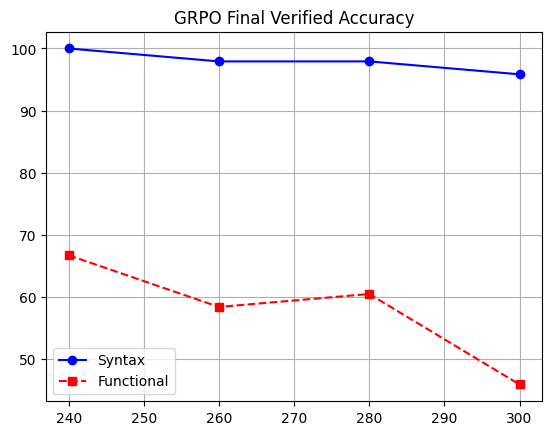

Successfully repaired and overwrote grpo_evaluation_results.json!


In [6]:
# Link the datasets already loaded in your Jupyter memory
meta_map = { item["prompt"]: {"cities": item["cities"], "durations": item["durations"]} for item in eval_dataset }

with open("grpo_evaluation_results.json", "r") as f:
    results = json.load(f)

new_summary = {}

for step, data in results.items():
    logs = data.get("detailed_logs", [])
    syn_succ = 0; func_succ = 0
    for log in logs:
        prompt = log.get("prompt_used", "")
        code = extract_code(log.get("generated_text", ""))
        meta = meta_map.get(prompt, {"cities": "", "durations": ""})
        
        is_syn, msg, plan = test_code_execution(code)
        
        # 1. NEW: Check function correctly and track boolean
        is_func = False
        if is_syn:
            syn_succ += 1
            if verify_plan(plan, meta["cities"], meta["durations"]):
                func_succ += 1
                is_func = True
                
        # 2. NEW: Overwrite the bad RunPod logs with your actual successful executions!
        log["syntax_passed"] = is_syn
        log["functional_passed"] = is_func
        log["execution_message"] = msg
                
    syn_acc = (syn_succ / len(logs)) * 100
    func_acc = (func_succ / len(logs)) * 100
    
    # 3. NEW: Save the repaired rigorous logs back into the dictionary!
    new_summary[step] = {
        "syntax": syn_acc, 
        "functional": func_acc,
        "detailed_logs": logs
    }
    
    print(f"Step {step} | Syntax: {syn_acc:.2f}% | Functional: {func_acc:.2f}%")

# Save directly back to the ORIGINAL file name to completely overwrite and repair it!
with open("grpo_evaluation_results.json", "w") as f:
    json.dump(new_summary, f, indent=4)

steps = sorted([int(k) for k in new_summary.keys()])
plt.plot(steps, [new_summary[str(s)]["syntax"] for s in steps], '-bo', label="Syntax")
plt.plot(steps, [new_summary[str(s)]["functional"] for s in steps], '--rs', label="Functional")
plt.legend(); plt.grid(True); plt.title("GRPO Final Verified Accuracy")
plt.savefig("grpo_final_graph.png")
plt.show()

print("Successfully repaired and overwrote grpo_evaluation_results.json!")

In [7]:
import json
import gc
import torch
from tqdm import tqdm
from unsloth import FastLanguageModel

# --- 1. SETTINGS ---
CHECKPOINT_PATH = "/workspace/ro4_reinforcement-learning/src/outputs/checkpoint-240"
max_seq_length = 4096

# Effective batch size on GPU = batch_size * N_SAMPLES = 4 * 5 = 20 scripts simultaneously.
batch_size = 4  
N_SAMPLES = 5   # Pass@5

print(f"Evaluating {CHECKPOINT_PATH.split('/')[-1]} with Pass@{N_SAMPLES} Inference...")

# Extract data into lists for easy batch slicing
all_prompts = [item["prompt"] for item in eval_dataset]
all_cities = [item["cities"] for item in eval_dataset]
all_durations = [item["durations"] for item in eval_dataset]

results_summary = {}
detailed_step_logs = []
syntax_success_count = 0
functional_success_count = 0

# --- 2. LOAD MODEL ---
print("Loading model and tokenizer...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = CHECKPOINT_PATH,
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# Configure Tokenizer for Batching
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --- 3. BATCH EVALUATION LOOP ---
for i in tqdm(range(0, len(all_prompts), batch_size), desc="Evaluating Pass@5"):
    batch_p = all_prompts[i : i + batch_size]
    batch_c = all_cities[i : i + batch_size]
    batch_d = all_durations[i : i + batch_size]

    # Format batch with Chat Template
    formatted_prompts = [
        tokenizer.apply_chat_template(
            [{"role": "user", "content": p}],
            tokenize=False,
            add_generation_prompt=True
        ) for p in batch_p
    ]

    # Tokenize batch
    inputs = tokenizer(
        formatted_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to("cuda")

    # Generate N samples in parallel
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3072,  
            temperature=0.6,                # Higher temperature for creativity
            do_sample=True,                 # Enable sampling
            num_return_sequences=N_SAMPLES, # 5 tries per prompt!
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True
        )

    # Slice out prompt and decode only new tokens
    prompt_length = inputs.input_ids.shape[1]
    decoded_outputs = tokenizer.batch_decode(outputs[:, prompt_length:], skip_special_tokens=True)

    # Group the flat output list back into chunks of N_SAMPLES per prompt
    grouped_outputs = [decoded_outputs[j : j + N_SAMPLES] for j in range(0, len(decoded_outputs), N_SAMPLES)]

    # Process results
    for gen_texts, c_str, d_str, original_p in zip(grouped_outputs, batch_c, batch_d, batch_p):
        
        prompt_passed_syntax = False
        prompt_passed_functional = False
        attempt_logs = []
        
        # Evaluate all N generated scripts for this specific prompt
        for text in gen_texts:
            code = extract_code(text)
            is_syntax_valid, msg, generated_plan = test_code_execution(code)
            is_functional = False
            
            if is_syntax_valid:
                prompt_passed_syntax = True # If at least 1 script runs, Syntax = True
                
                if verify_plan(generated_plan, c_str, d_str):
                    is_functional = True
                    prompt_passed_functional = True # If at least 1 script solves it, Functional = True
            
            attempt_logs.append({
                "generated_text": text,
                "execution_message": msg,
                "syntax_passed": is_syntax_valid,
                "functional_passed": is_functional,
            })
                
        # Tally final score for this prompt
        if prompt_passed_syntax:
            syntax_success_count += 1
        if prompt_passed_functional:
            functional_success_count += 1
            
        detailed_step_logs.append({
            "prompt_used": original_p,
            "overall_syntax": prompt_passed_syntax,
            "overall_functional": prompt_passed_functional,
            "attempts": attempt_logs
        })

# --- 4. RECORD RESULTS ---
total = len(eval_dataset)
syntax_acc = (syntax_success_count / total) * 100
functional_acc = (functional_success_count / total) * 100

results_summary["checkpoint-240"] = {
    "syntax": syntax_acc, 
    "functional": functional_acc,
    "detailed_logs": detailed_step_logs
}

# Save results
output_filename = f"grpo_pass{N_SAMPLES}_checkpoint-240_results.json"
with open(output_filename, "w") as f:
    json.dump(results_summary, f, indent=4)

# Clean Memory
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()

# --- 5. FINAL SUMMARY PRINT ---
print("\n" + "*"*50)
print(f"FINAL EVALUATION SUMMARY (Pass@{N_SAMPLES}) - Checkpoint 240")
print("-" * 50)
print(f"Syntax Accuracy:        {syntax_acc:.2f}%")
print(f"Functional Correctness: {functional_acc:.2f}%")
print("*"*50)
print(f"Detailed logs saved to: {output_filename}")

Evaluating checkpoint-240 with Pass@5 Inference...
Loading model and tokenizer...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 6000 Ada Generation. Num GPUs = 1. Max memory: 47.382 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Evaluating Pass@5: 100%|██████████| 12/12 [49:33<00:00, 247.82s/it]



**************************************************
FINAL EVALUATION SUMMARY (Pass@5) - Checkpoint 240
--------------------------------------------------
Syntax Accuracy:        100.00%
Functional Correctness: 81.25%
**************************************************
Detailed logs saved to: grpo_pass5_checkpoint-240_results.json


In [8]:
import json

# Load your Pass@5 results
filename = "grpo_pass5_checkpoint-240_results.json"

with open(filename, "r") as f:
    data = json.load(f)

# Navigate to the detailed logs
logs = data["checkpoint-240"]["detailed_logs"]
total_prompts = len(logs)

# Dictionaries to hold our success counts
pass_k_success = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

for item in logs:
    attempts = item["attempts"]
    
    # Check Pass@1 (Did the very 1st attempt pass?)
    if any(a["functional_passed"] for a in attempts[0:1]): pass_k_success[1] += 1
    
    # Check Pass@2 (Did at least one of the first 2 attempts pass?)
    if any(a["functional_passed"] for a in attempts[0:2]): pass_k_success[2] += 1
    
    # Check Pass@3 (Did at least one of the first 3 attempts pass?)
    if any(a["functional_passed"] for a in attempts[0:3]): pass_k_success[3] += 1
    
    # Check Pass@4 (Did at least one of the first 4 attempts pass?)
    if any(a["functional_passed"] for a in attempts[0:4]): pass_k_success[4] += 1
    
    # Check Pass@5 (Did at least one of all 5 attempts pass?)
    if any(a["functional_passed"] for a in attempts[0:5]): pass_k_success[5] += 1

# Print the final table for your thesis!
print(f"Total Validation Prompts: {total_prompts}")
print("-" * 30)
for k in range(1, 6):
    accuracy = (pass_k_success[k] / total_prompts) * 100
    print(f"Pass@{k} Accuracy: {accuracy:.2f}%")
print("-" * 30)

Total Validation Prompts: 48
------------------------------
Pass@1 Accuracy: 39.58%
Pass@2 Accuracy: 52.08%
Pass@3 Accuracy: 70.83%
Pass@4 Accuracy: 75.00%
Pass@5 Accuracy: 81.25%
------------------------------
